<a href="https://colab.research.google.com/github/guanyuq03/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Class%2015/%5BLab_15%5D_The_Architecture_of_Generalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

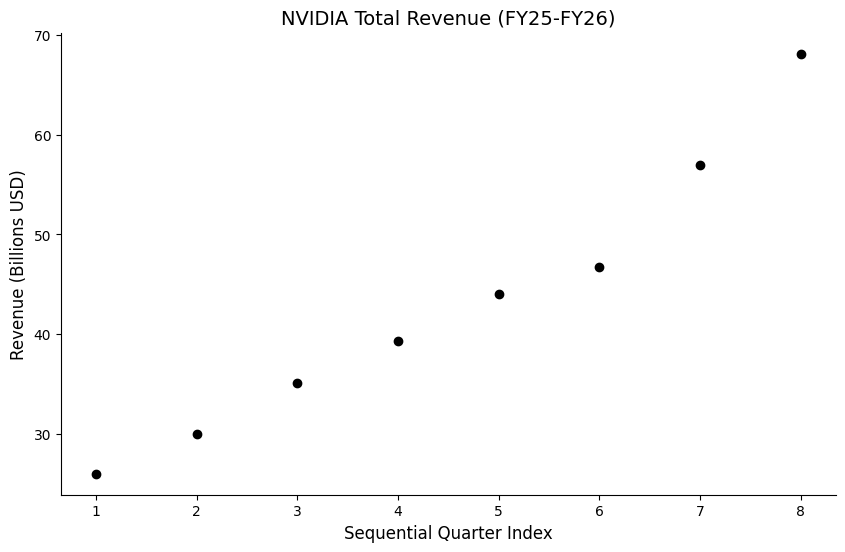

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

# Step 1: Ingestion of Modernized NVIDIA Dataset
# Data reflects the massive AI infrastructure capex boom of 2024-2026

data = {
    'Time_Index': np.array([1, 2, 3, 4, 5, 6, 7, 8]),
    'Total_Revenue_Billions': np.array([26.04, 30.04, 35.10, 39.33, 44.06, 46.74, 57.00, 68.10])
}
df = pd.DataFrame(data)

X = df[['Time_Index']]
y = df['Total_Revenue_Billions']

# Visual EDA (Adhering to Data-Ink Ratio principles)
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.title('NVIDIA Total Revenue (FY25-FY26)', fontsize=14)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

Linear Training MSE (High Bias): 7.91


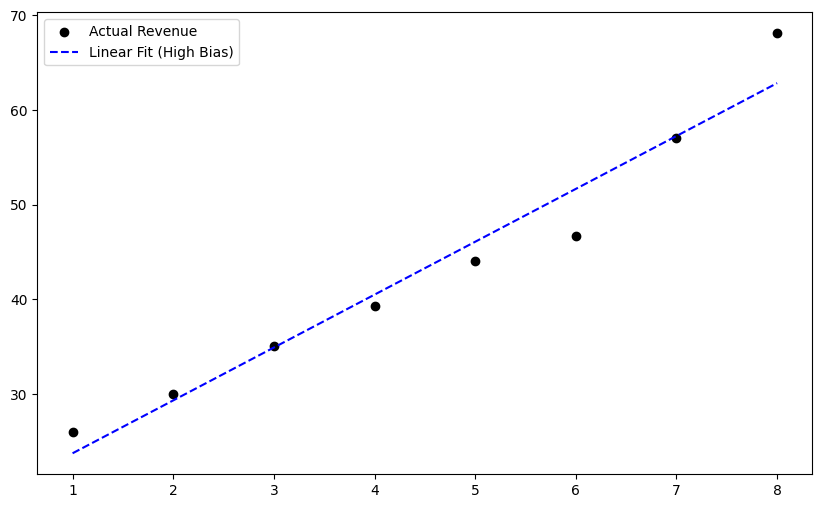

In [2]:
# Step 2: High Bias (Underfitting) Linear Model
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_linear = lin_reg.predict(X)
mse_linear = mean_squared_error(y, y_pred_linear)

print(f"Linear Training MSE (High Bias): {mse_linear:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.plot(X, y_pred_linear, color='blue', linestyle='--', label='Linear Fit (High Bias)')
plt.legend()
plt.show()

Polynomial Degree-7 Training MSE (High Variance): 0.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


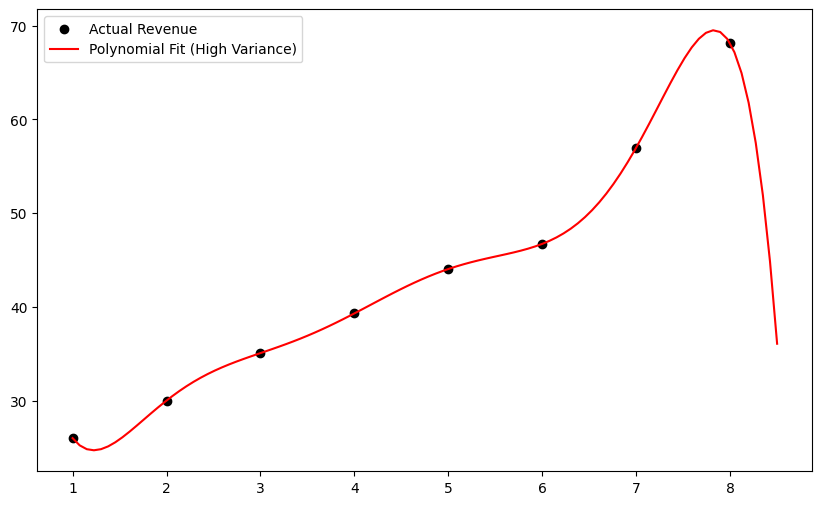

In [4]:
# Step 3: High Variance (Overfitting) Polynomial Model
poly_features = PolynomialFeatures(degree=7, include_bias=False)
X_poly = poly_features.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_pred_poly = poly_reg.predict(X_poly)
mse_poly = mean_squared_error(y, y_pred_poly)

print(f"Polynomial Degree-7 Training MSE (High Variance): {mse_poly:.2f}")

# Plotting the smooth polynomial curve
X_smooth = np.linspace(1, 8.5, 100).reshape(-1, 1)
X_smooth_poly = poly_features.transform(X_smooth)
y_smooth_poly = poly_reg.predict(X_smooth_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.plot(X_smooth, y_smooth_poly, color='red', label='Polynomial Fit (High Variance)')
plt.legend()
plt.show()

In [5]:
# Step 4: The Extrapolation Collapse
X_future = np.array([[9]])  # Forecasting Q1 FY27
X_future_poly = poly_features.transform(X_future)
future_pred = poly_reg.predict(X_future_poly)

print(f"\nHallucinated Q1 FY27 Revenue Prediction: ${future_pred[0]:.2f} Billion")


Hallucinated Q1 FY27 Revenue Prediction: $-84.00 Billion


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [6]:
# Step 5: K-Fold Cross Validation
cv_scores = cross_val_score(poly_reg, X_poly, y, cv=4, scoring='neg_mean_squared_error')
mean_cv_mse = -cv_scores.mean()

print(f"K-Fold Cross-Validated MSE (The True Operational Error): {mean_cv_mse:.2f}")

K-Fold Cross-Validated MSE (The True Operational Error): 8641.58


AI expansion

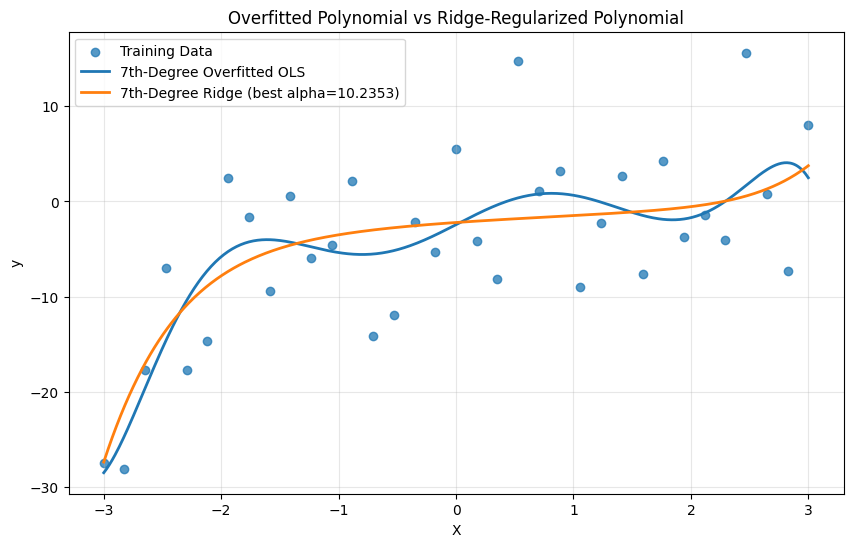

Overfitted model CV MSE: 122.2134
Ridge model CV MSE:      75.8836
Best alpha from RidgeCV: 10.235310

Overfitted OLS coefficients:
[ 11.30925975   0.55283419 -46.83423614  -2.75939588  78.75415796
  -0.85212996 -36.5679686 ]

Ridge coefficients (shrunk toward zero):
[ 1.53654447 -0.67072806  1.41453024 -1.00356023  1.5720512  -1.1460322
  1.55760861]


In [7]:
# Ridge-regularized polynomial regression with automatic alpha tuning
# ---------------------------------------------------------------
# Goal:
# 1) Recreate a high-variance 7th-degree polynomial model
# 2) Use RidgeCV with 4-Fold Cross-Validation to choose the best alpha
# 3) Plot the regularized curve against the original overfitted curve
# 4) Compare cross-validated MSE values for predictive stability

import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import KFold, cross_val_score

# ---------------------------------------------------------------
# Example data
# Replace X and y with your lab data if you already have it
# X must be 2D for scikit-learn: shape (n_samples, 1)
# ---------------------------------------------------------------
np.random.seed(42)
X = np.linspace(-3, 3, 35).reshape(-1, 1)
y = 0.5 * X.ravel()**3 - 2 * X.ravel()**2 + X.ravel() + 3
y = y + np.random.normal(scale=8, size=len(y))  # add noise to encourage overfitting

# ---------------------------------------------------------------
# Common CV strategy: 4-Fold Cross-Validation
# shuffle=True improves robustness when data are ordered
# ---------------------------------------------------------------
cv = KFold(n_splits=4, shuffle=True, random_state=42)

# ---------------------------------------------------------------
# 1) Original overfitted model: 7th-degree polynomial + OLS
#    This model has no penalty, so coefficients can grow very large
#    and bend aggressively to chase noise (high variance).
# ---------------------------------------------------------------
overfit_model = Pipeline([
    ("poly", PolynomialFeatures(degree=7, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])

overfit_model.fit(X, y)

# Cross-validated MSE for the overfitted model
# cross_val_score returns NEGATIVE MSE, so we flip the sign
overfit_cv_mse = -cross_val_score(
    overfit_model, X, y, cv=cv, scoring="neg_mean_squared_error"
).mean()

# ---------------------------------------------------------------
# 2) Ridge-regularized model with automatic alpha selection
#    Ridge adds an L2 penalty to the loss function:
#
#    Loss = SSE + alpha * sum(coef^2)
#
#    The alpha * sum(coef^2) term explicitly punishes large weights.
#    That means coefficients are SHRUNK toward zero.
#
#    Why this helps:
#    - Large polynomial coefficients create wild curve oscillations
#    - Shrinking them makes the curve smoother
#    - A smoother curve is less sensitive to noise
#    - Less sensitivity to noise = lower variance
# ---------------------------------------------------------------

# Candidate alpha values to test automatically
alphas = np.logspace(-4, 4, 100)

ridge_model = Pipeline([
    ("poly", PolynomialFeatures(degree=7, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridgecv", RidgeCV(alphas=alphas, cv=cv, scoring="neg_mean_squared_error"))
])

ridge_model.fit(X, y)

# Best alpha selected by 4-fold CV
best_alpha = ridge_model.named_steps["ridgecv"].alpha_

# Cross-validated MSE for the ridge model
ridge_cv_mse = -cross_val_score(
    ridge_model, X, y, cv=cv, scoring="neg_mean_squared_error"
).mean()

# ---------------------------------------------------------------
# 3) Create smooth grid for plotting model curves
# ---------------------------------------------------------------
X_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)

y_overfit_plot = overfit_model.predict(X_plot)
y_ridge_plot = ridge_model.predict(X_plot)

# ---------------------------------------------------------------
# 4) Plot data, overfitted curve, and ridge-regularized curve
# ---------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label="Training Data", alpha=0.75)
plt.plot(X_plot, y_overfit_plot, label="7th-Degree Overfitted OLS", linewidth=2)
plt.plot(
    X_plot,
    y_ridge_plot,
    label=f"7th-Degree Ridge (best alpha={best_alpha:.4f})",
    linewidth=2
)
plt.title("Overfitted Polynomial vs Ridge-Regularized Polynomial")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---------------------------------------------------------------
# 5) Print model comparison
# ---------------------------------------------------------------
print(f"Overfitted model CV MSE: {overfit_cv_mse:.4f}")
print(f"Ridge model CV MSE:      {ridge_cv_mse:.4f}")
print(f"Best alpha from RidgeCV: {best_alpha:.6f}")

# ---------------------------------------------------------------
# 6) Inspect coefficient shrinkage
#    Ridge does NOT usually make coefficients exactly zero.
#    Instead, it shrinks them toward zero.
#    Smaller magnitudes usually mean less chaotic curve behavior.
# ---------------------------------------------------------------
overfit_coefs = overfit_model.named_steps["linreg"].coef_
ridge_coefs = ridge_model.named_steps["ridgecv"].coef_

print("\nOverfitted OLS coefficients:")
print(overfit_coefs)

print("\nRidge coefficients (shrunk toward zero):")
print(ridge_coefs)